# 💬 Day 20 - SMS Spam Detection using Naive Bayes

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load data (Kaggle SMS Spam Collection)
df = pd.read_csv("spam.csv", encoding="latin-1")

# Many Kaggle versions have extra unnamed columns; we drop them
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print(df.shape)
print(df['label'].value_counts())

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows")

Removed 403 duplicate rows


In [5]:
df['text_length'] = df['text'].apply(len)

df.groupby('label')['text_length'].mean()

label
ham      70.459256
spam    137.891271
Name: text_length, dtype: float64

In [6]:
X = df['text']
y = df['label']   # 'ham' or 'spam'

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 4135
Test size: 1034


In [7]:
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=3000  # cap vocab for simplicity
    )),
    ('nb', MultinomialNB())
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=3000, stop_words='english')),
                ('nb', MultinomialNB())])

In [8]:
y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

Classification Report:

              precision    recall  f1-score   support

         ham      0.971     0.999     0.985       903
        spam      0.990     0.794     0.881       131

    accuracy                          0.973      1034
   macro avg      0.981     0.896     0.933      1034
weighted avg      0.973     0.973     0.972      1034



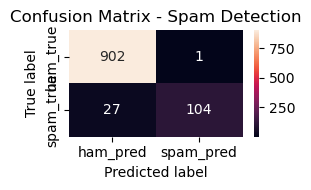

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

plt.figure(figsize=(3,2))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['ham_pred', 'spam_pred'],
            yticklabels=['ham_true', 'spam_true'])
plt.title("Confusion Matrix - Spam Detection")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

spam_precision = precision_score(y_test, y_pred, pos_label='spam')
spam_recall = recall_score(y_test, y_pred, pos_label='spam')
spam_f1 = f1_score(y_test, y_pred, pos_label='spam')

print("Spam Precision:", round(spam_precision, 3))
print("Spam Recall:", round(spam_recall, 3))
print("Spam F1:", round(spam_f1, 3))

Spam Precision: 0.99
Spam Recall: 0.794
Spam F1: 0.881


In [11]:
def classify_message(msg: str):
    pred = model.predict([msg])[0]
    prob = model.predict_proba([msg])[0]
    spam_prob = prob[list(model.classes_).index('spam')]
    return pred, spam_prob

examples = [
    "Congratulations! You have won a free lottery ticket. Click here to claim.",
    "Hi, are we still meeting at 5 pm today?",
    "Your OTP is 456789. Please do not share it with anyone."
]

for msg in examples:
    label, p_spam = classify_message(msg)
    print(f"Message: {msg}")
    print(f"Predicted: {label}, Spam probability: {p_spam:.3f}")
    print("-" * 60)

Message: Congratulations! You have won a free lottery ticket. Click here to claim.
Predicted: spam, Spam probability: 0.871
------------------------------------------------------------
Message: Hi, are we still meeting at 5 pm today?
Predicted: ham, Spam probability: 0.018
------------------------------------------------------------
Message: Your OTP is 456789. Please do not share it with anyone.
Predicted: ham, Spam probability: 0.125
------------------------------------------------------------


In [12]:
tfidf = model.named_steps['tfidf']
nb = model.named_steps['nb']

feature_names = np.array(tfidf.get_feature_names_out())
# Naive Bayes has log probabilities per class; we look at spam class
spam_class_index = list(nb.classes_).index('spam')
spam_log_probs = nb.feature_log_prob_[spam_class_index]

top_n = 20
top_spam_indices = np.argsort(spam_log_probs)[-top_n:]
top_spam_words = feature_names[top_spam_indices]

print('Top spam words:', top_spam_words)

Top spam words: ['150p' 'com' 'service' 'win' 'contact' 'urgent' 'cash' 'uk' 'won' 'new'
 'www' 'prize' 'ur' 'claim' 'stop' 'reply' 'text' 'txt' 'mobile' 'free']
